In [ ]:
#Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../data/raw/sleep_mobile_stress_dataset_15000.csv')

In [ ]:
#Hacemos un pequeño análisis inicial

df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [ ]:
df.info() #vemos que hay varias variables como str que tendremos que modificar

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  str    
 3   occupation                        15000 non-null  str    
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  mental_fatigue_

In [6]:
#Ya vemos que no hay nulos pero aun asi lo comprobamos
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe() #no parece que haya ningun outlier, todo son variables bastante normales

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


Como comentario tenemos que ver que hacemos con las variables categoricas, gender probablemente hagamos un mapeo de ella con 0 y 1 para hombre o mujer, el resto habrá que ver como abordarlas, también nos vamos a cargar el id ya que no nos aporta nada

In [ ]:
df.drop(columns=['user_id'], inplace=True) #no nos aporta nada de info para el modelo, asi que la eliminamos

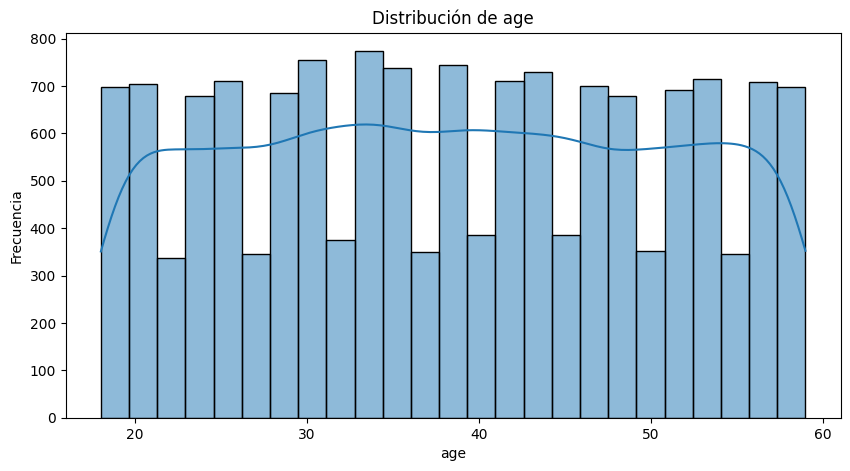

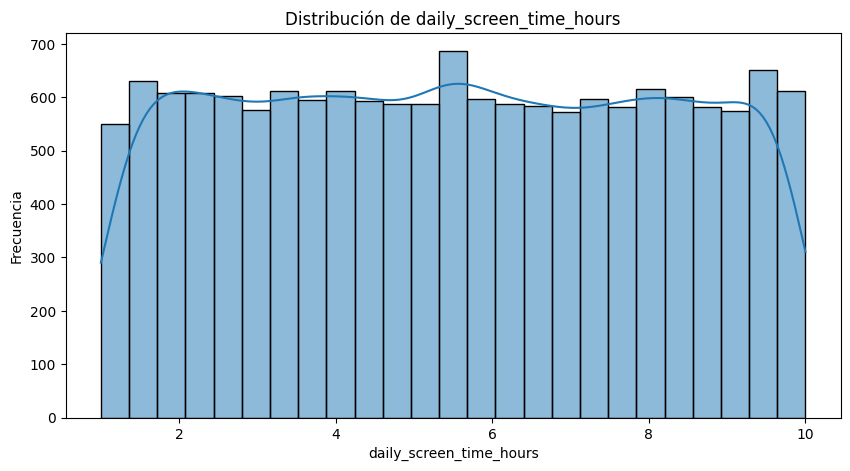

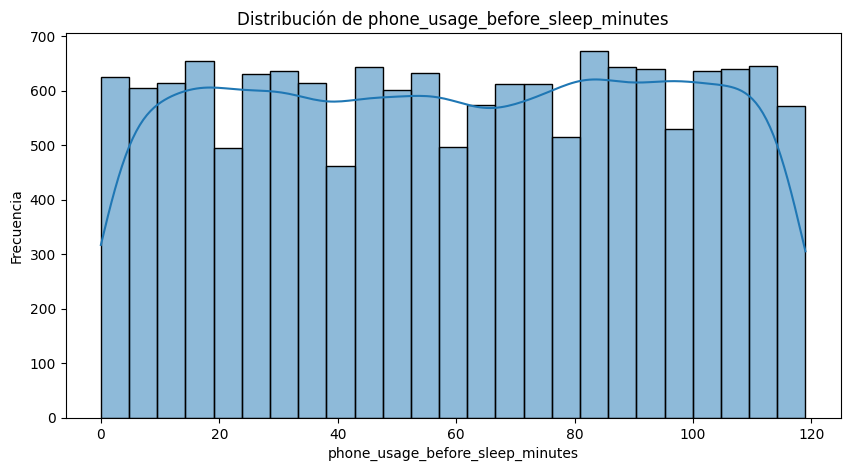

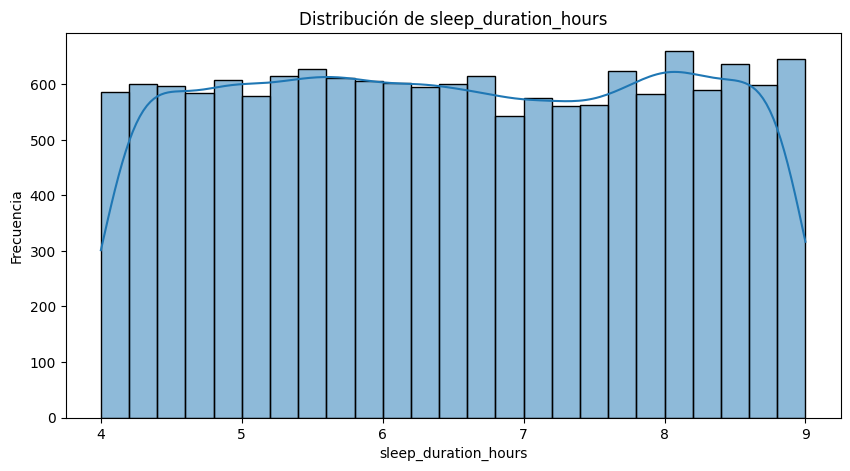

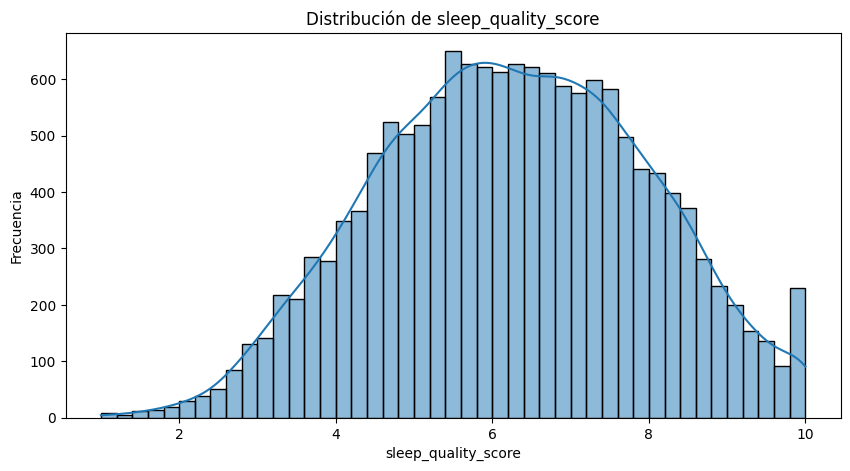

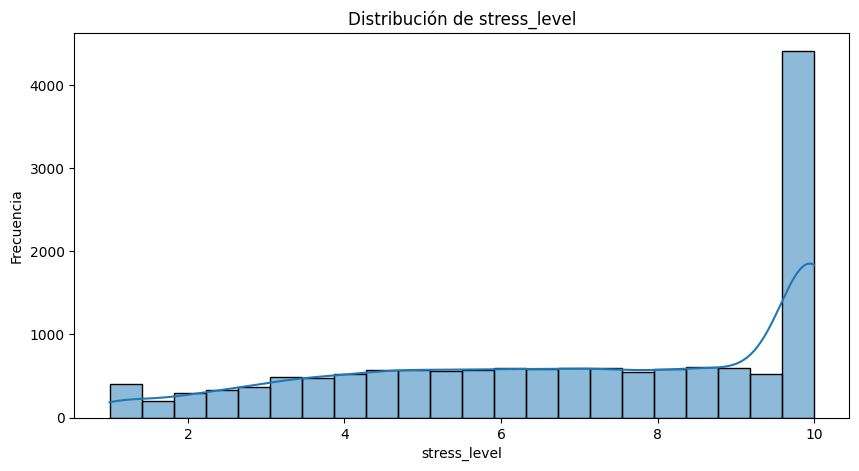

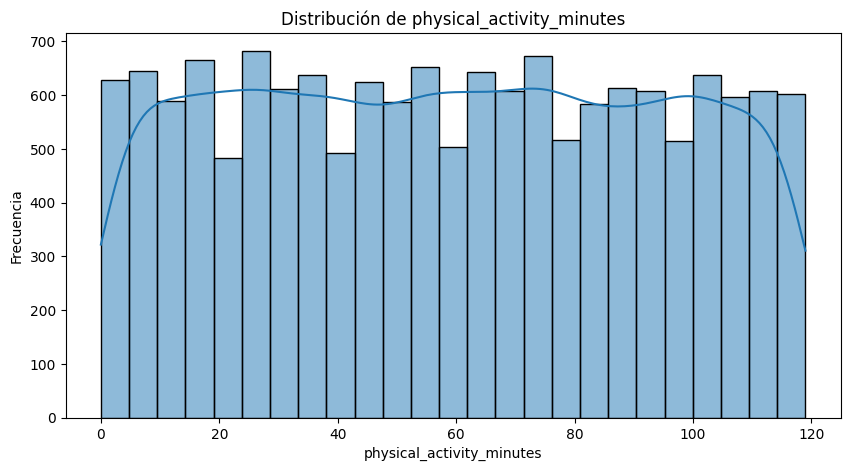

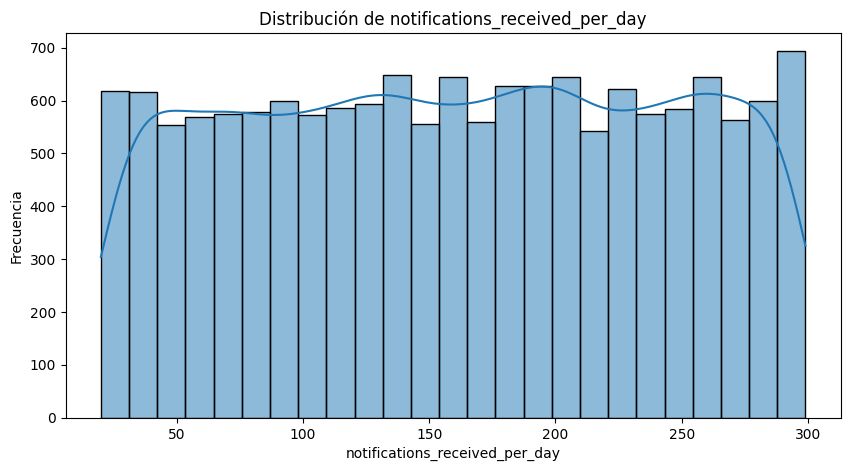

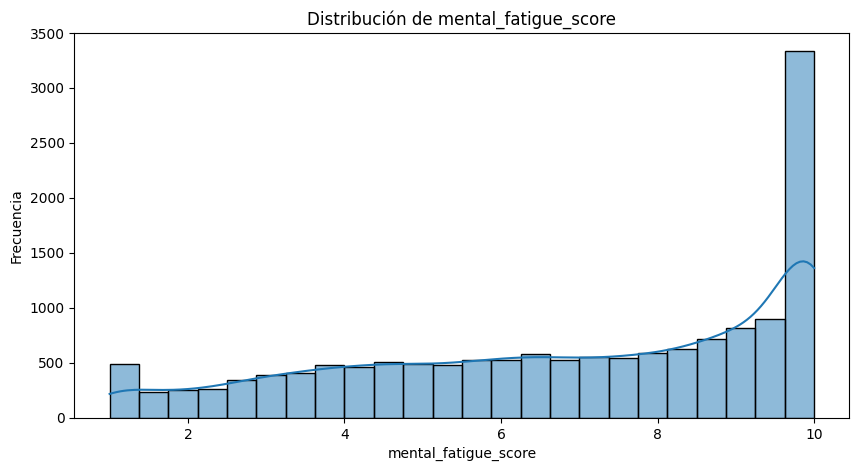

In [ ]:
# Empezamos por el analisis univariante de cada variable

columnas_numericas = df.select_dtypes(include=['int64', 'float64'])
columnas_numericas = columnas_numericas.drop(columns=['caffeine_intake_cups']).columns #estas dos variables las dejaremos para el analisis bivariante

for columns in columnas_numericas:
    plt.figure(figsize=(10,5))
    sns.histplot(df[columns], kde=True)
    plt.title(f'DistribuciÃ³n de {columns}')
    plt.xlabel(columns)
    plt.ylabel('Frecuencia')
    plt.show()

#Por aqui todo correcto, valores muy correctos y con edades que tienen bastante sentido para un estudio 

"""SORPRENDE MUCHO ver que hay muchisima gente con mucho estrés y que mucha gente gasta hasta 10 horas
con el móvil al día"""

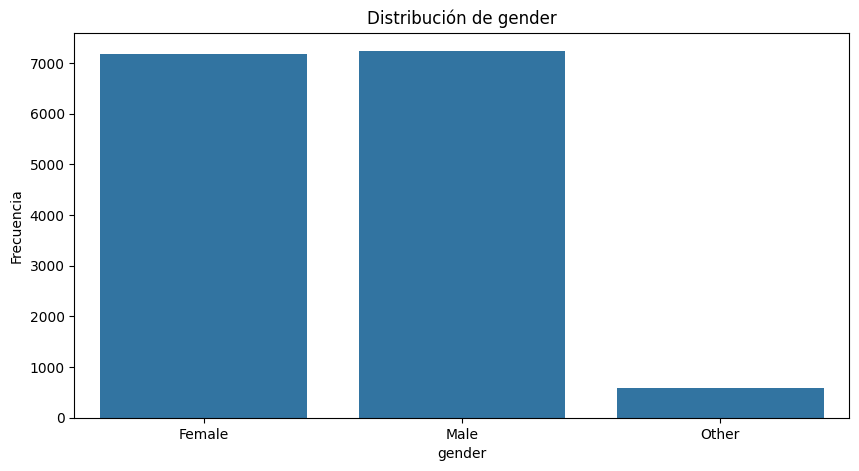

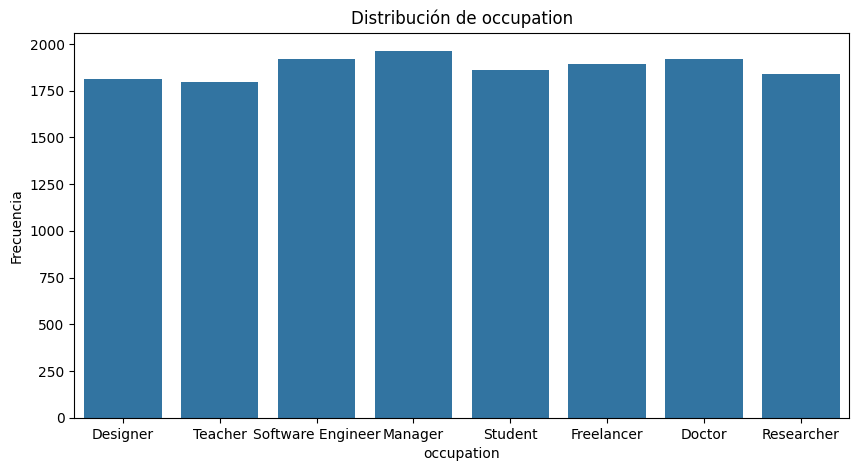

In [19]:
#Ahora me toca ver la variable discreta caffeine asi como las variables de str

columnas_categoricas = df.select_dtypes(include=['str']).columns
for columns in columnas_categoricas:
    plt.figure(figsize=(10,5))
    sns.countplot(x=df[columns])
    plt.title(f'DistribuciÃ³n de {columns}')
    plt.xlabel(columns)
    plt.ylabel('Frecuencia')
    plt.show()

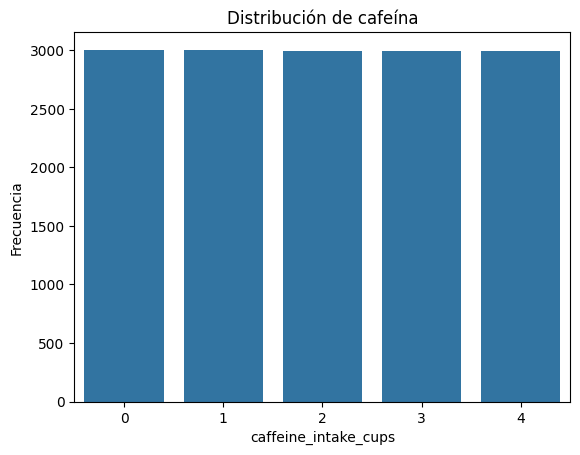

In [ ]:
#Aqui la variable cafeína
sns.countplot(x=df['caffeine_intake_cups'])
plt.title('DistribuciÃ³n de cafeÃ­na')
plt.xlabel('caffeine_intake_cups')
plt.ylabel('Frecuencia')
plt.show()

A priori parece un dataset super interesante para hacer un analisis, los datos están muy balanceadas y hay una gran cantidad lo que implica que los resultados van a ser fiables

Text(0.5, 1.0, 'Mapa de calor de correlaciÃ³n')

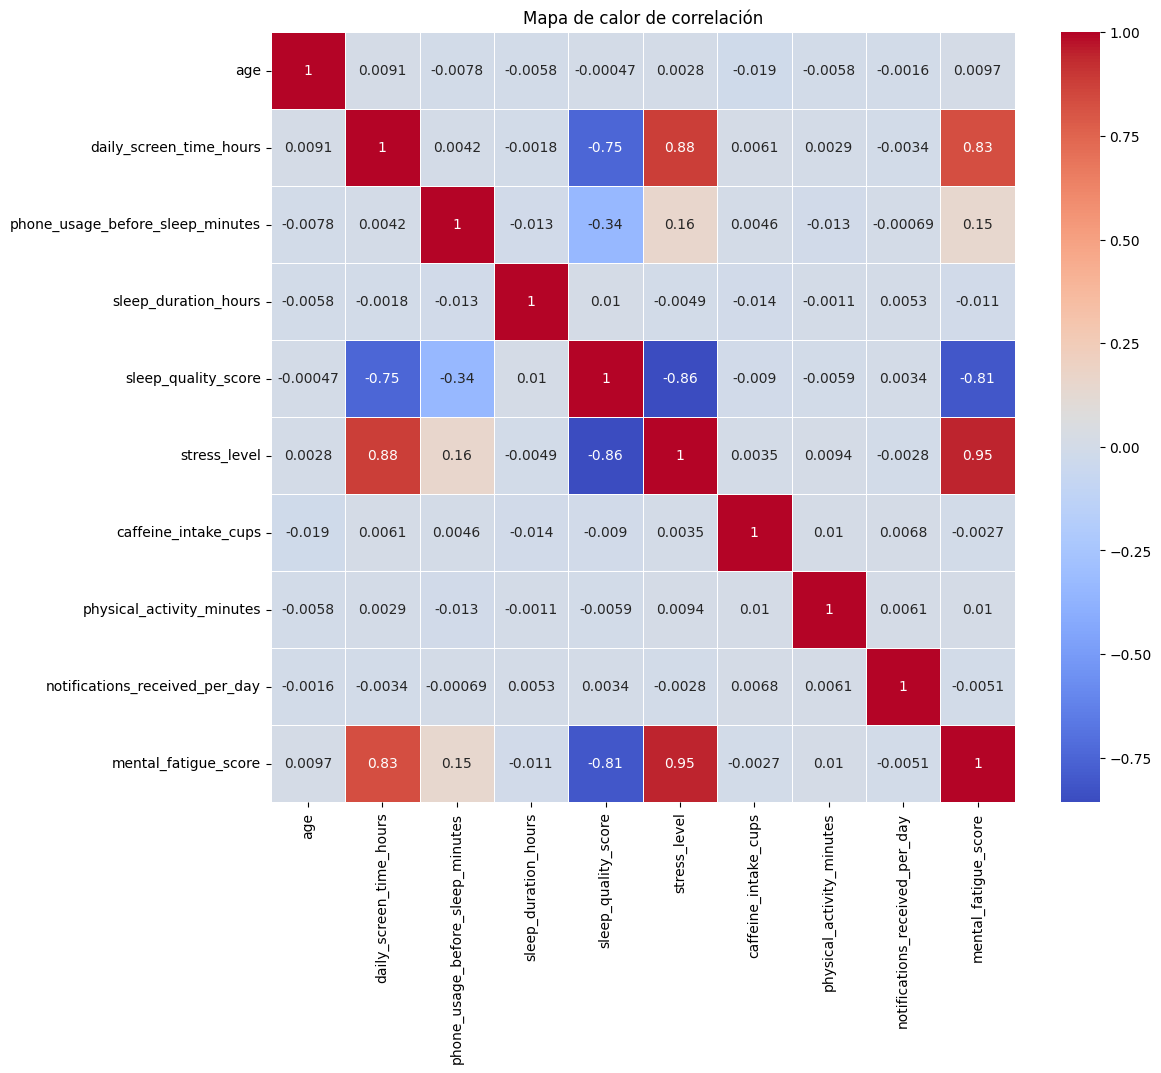

In [ ]:
#Finalmente miramos la correlación entre las variables numéricas
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de calor de correlación')

Aqui aparecen las primeras cosas a tener en cuenta, son interesantes desde el punto de vista humano donde vemos que hay correlación directa el estrés y la fatiga mental o lo bien o mal que duermes y la fatiga mental, que son cosas que sabemos que pasan de normal. Por como es la estructura un modelo de arboles puede parecer que nos va a venir bastante bien, por lo que no va a ser un problema estos valores tan elevados.

También va a ser muy interesante jugar con quitar o poner la info o crear nuevas variables para ver como cambia el benchmark.

In [ ]:
# Preparamos un subconjunto específico para relaciones multivariantes entre 3 variables (las tres más interesantes)
variables_multivariantes = [
    'mental_fatigue_score',
    'daily_screen_time_hours',
    'sleep_quality_score'
 ]
objetivo = 'stress_level'
df_multivar = df[variables_multivariantes + [objetivo, 'gender']].copy()
df_multivar.head()

,mental_fatigue_score,daily_screen_time_hours,sleep_quality_score,stress_level,gender
0,3.57,3.26,7.72,3.49,Female
1,1.91,1.85,9.70,3.01,Female
2,6.05,3.04,6.38,5.03,Female
3,9.92,9.00,5.53,10.00,Male
4,5.99,3.52,6.69,6.71,Female


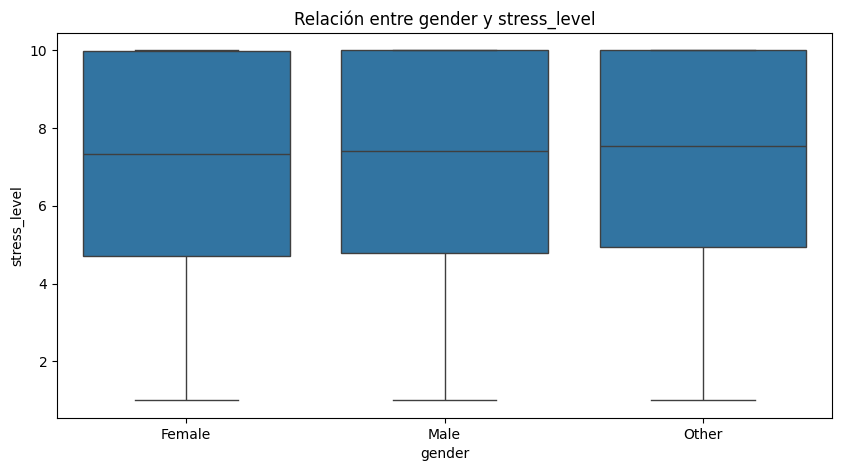

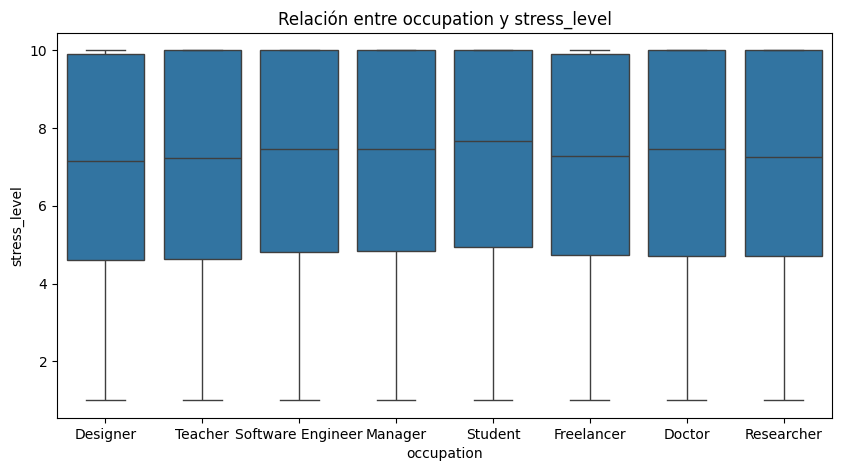

In [ ]:
columnas_categoricas = df.select_dtypes(include=['str']).columns
for columns in columnas_categoricas:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[columns], y=df['stress_level'])
    plt.title(f'Relación entre {columns} y stress_level')
    plt.xlabel(columns)
    plt.ylabel('stress_level')
    plt.show()

A primera vista no parece que ningun caso destaque sobre el resto estando bastante bien distribuidas en general

Text(0.5, 1.0, 'RelaciÃ³n entre cafeÃ­na y stress_level')

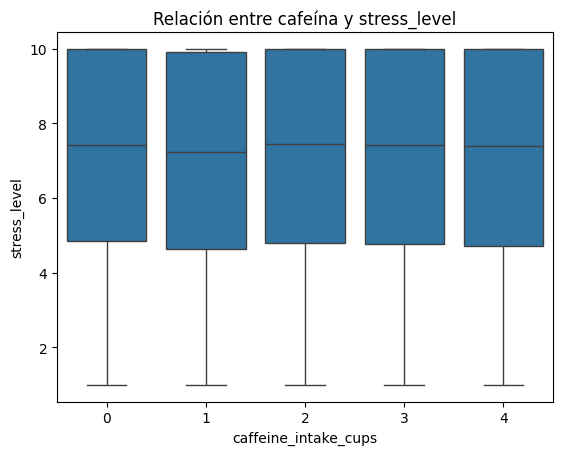

In [ ]:
#Finalmente queda cafeina

sns.boxplot(x=df['caffeine_intake_cups'], y=df['stress_level'])
plt.title('Relación entre cafeína y stress_level')

#Y una vez más vemos que el consumo de cafeína no parece tener una relación clara, por lo que las variables
#más clara son las mencionadas anteriormente 

<Axes: >

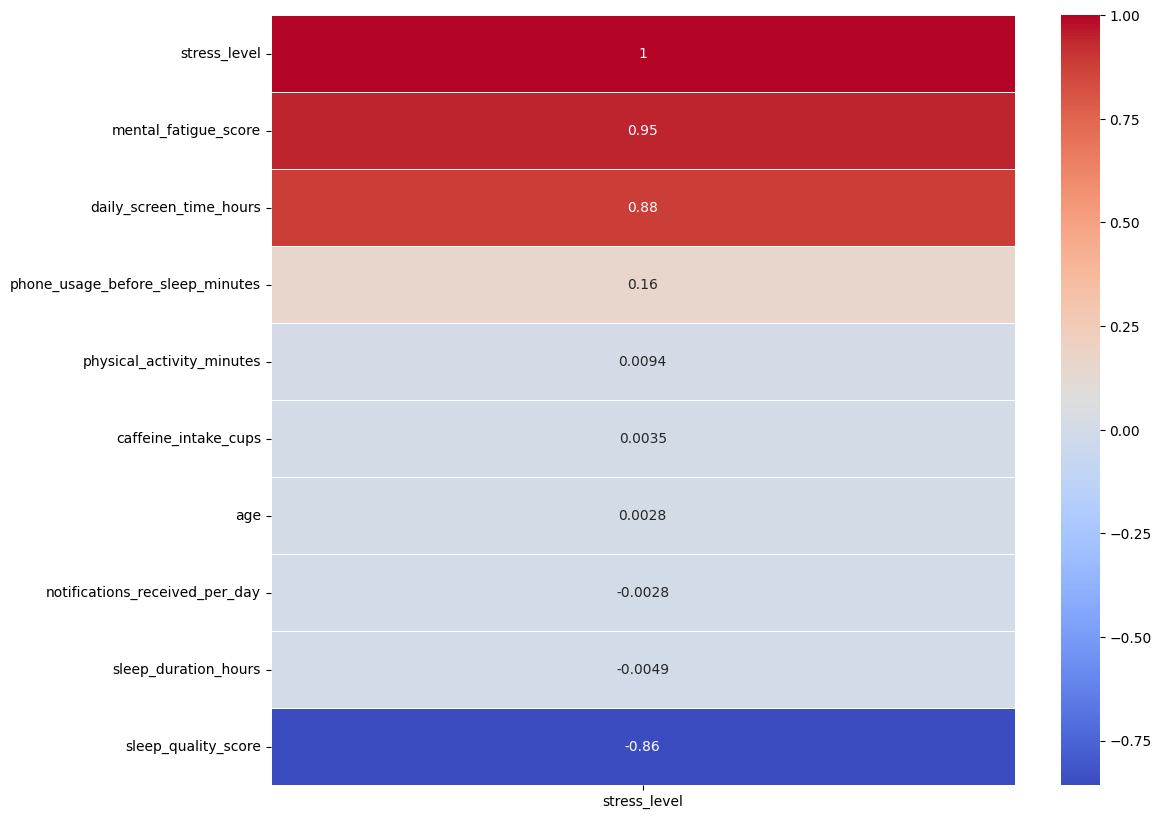

In [ ]:
#Ahora podemos añadir la correlación ya no entre ellas si no con el target
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include=['number']).corr()['stress_level'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm', linewidths=0.5)

#Como veíamos y hemos tratado de hablar, las variables que más correlación tienen son las que se ven a priori en el modelo 

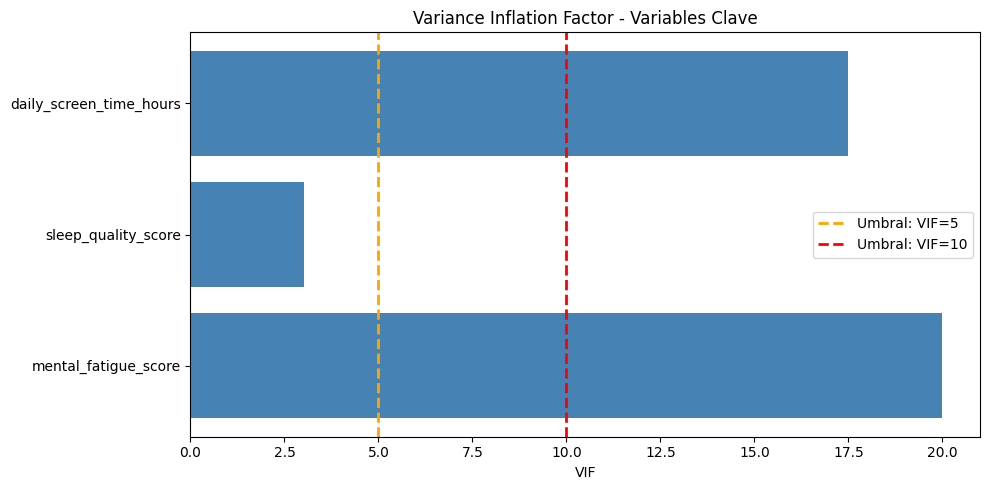

In [ ]:
# Análisis de Multicolinealidad: VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Variables clave identificadas
variables_clave = ['mental_fatigue_score', 'sleep_quality_score', 'daily_screen_time_hours']
X = df[variables_clave]

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data['Variable'] = variables_clave
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Visualizar
plt.figure(figsize=(10, 5))
plt.barh(vif_data['Variable'], vif_data['VIF'], color='steelblue')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Umbral: VIF=5')
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Umbral: VIF=10')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor - Variables Clave')
plt.legend()
plt.tight_layout()
plt.show()

Recordamos que voy a usar algoritmos con Ã¡rboles entonces el Luis no es Tan importante Sin embargo lo calculo porque si luego hago un benchmark con una regresiÃ³n logÃ­stica sÃ­ que hay que tenerlo en cuenta Ya que son coeficientes lineales.

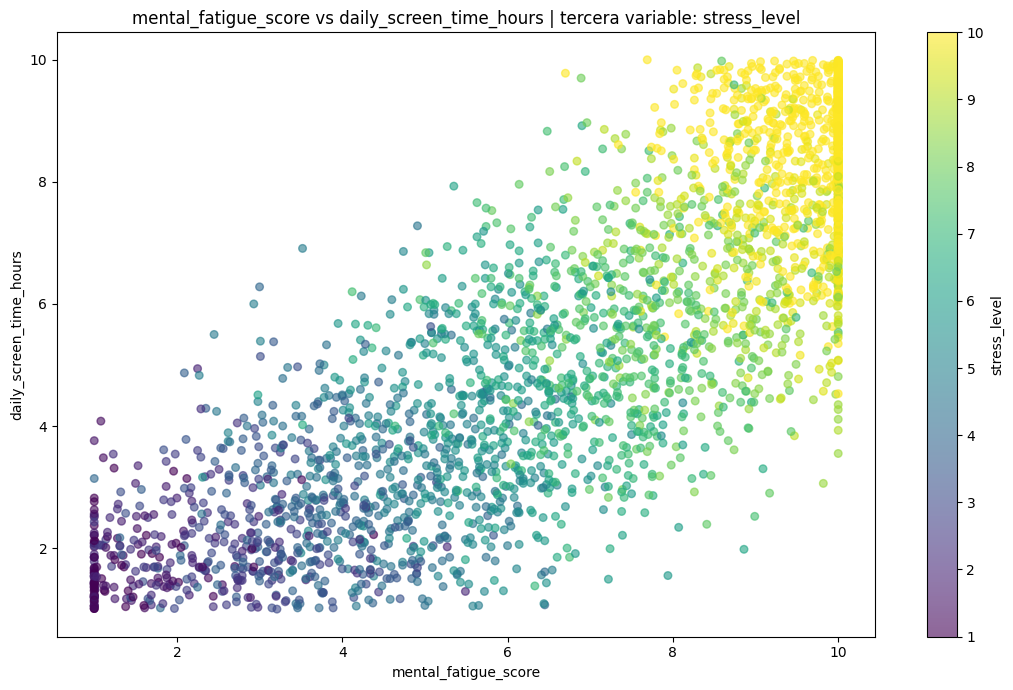

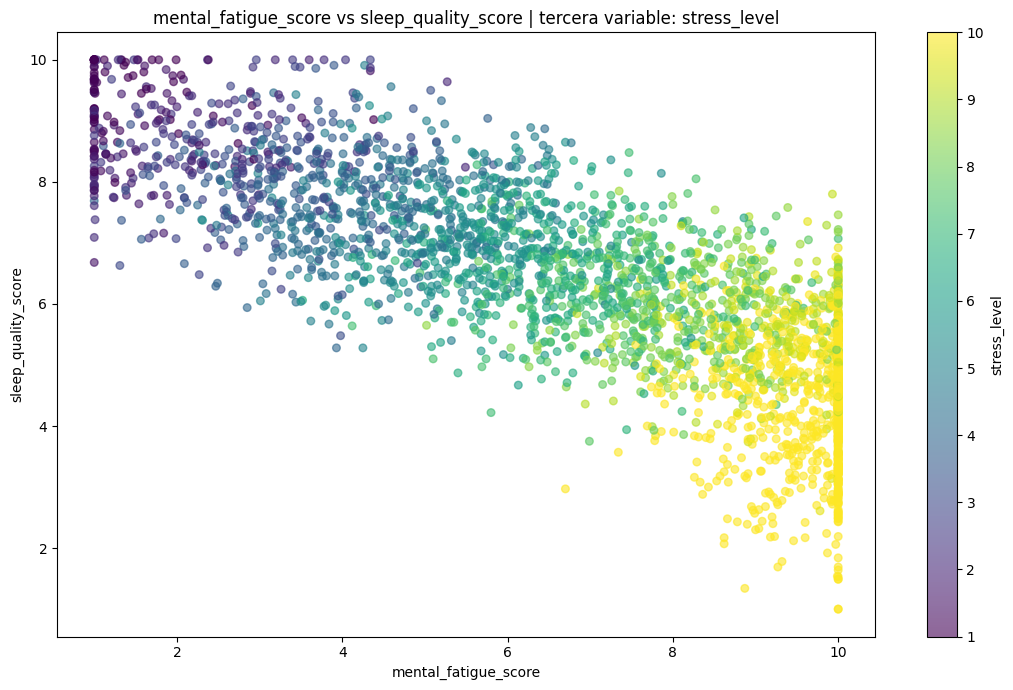

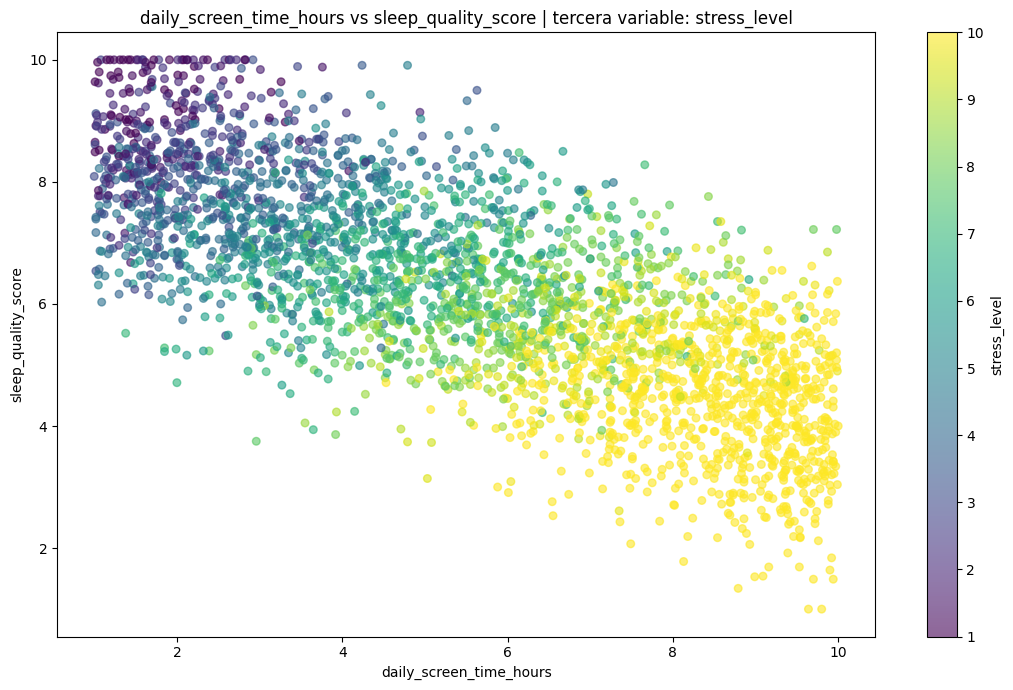

In [5]:
# Analisis multivariante para prediccion de stress_level
# 2 variables en ejes + tercera variable (objetivo) en color
columnas_modelo = [
    'mental_fatigue_score',
    'daily_screen_time_hours',
    'sleep_quality_score'
 ]
objetivo = 'stress_level'

muestra_multivar = df.sample(n=3000, random_state=42) if len(df) > 3000 else df.copy()

combinaciones = [
    ('mental_fatigue_score', 'daily_screen_time_hours'),
    ('mental_fatigue_score', 'sleep_quality_score'),
    ('daily_screen_time_hours', 'sleep_quality_score')
 ]

for x_var, y_var in combinaciones:
    plt.figure(figsize=(11, 7))
    scatter = plt.scatter(
        muestra_multivar[x_var],
        muestra_multivar[y_var],
        c=muestra_multivar[objetivo],
        cmap='viridis',
        alpha=0.6,
        s=30
    )
    cbar = plt.colorbar(scatter)
    cbar.set_label('stress_level')
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.title(f'{x_var} vs {y_var} | tercera variable: stress_level')
    plt.tight_layout()
    plt.show()

Vemos patrones claros y consistentes:
- A mayor `mental_fatigue_score` y `daily_screen_time_hours`, mayor `stress_level`.
- A menor `sleep_quality_score`, mayor `stress_level`.

Con esto, hacemos feature engineering con sumas y multiplicaciones para capturar interacciones no lineales y dejar preparado el dataset para regresión y clasificación.

In [ ]:
# Feature engineering sin leakage + no linealidad + codificacion de categoricas
from sklearn.model_selection import train_test_split

df_model = df.copy()

#esta es una buena manera de crear un target de clasificación a partir del target de regresión
    df_model['stress_level'],
    bins=[0, 4, 7, 10],
    labels=['bajo', 'medio', 'alto'],
    include_lowest=True
)
#hacemos split antes para evitar data leakage
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model['stress_level_class']
)

def crear_features(df_entrada):
    df_salida = df_entrada.copy()

    # Variables base transformadas
    df_salida['poor_sleep_score'] = 11 - df_salida['sleep_quality_score']

    # Features aditivas
    df_salida['fatigue_screen_sum'] = df_salida['mental_fatigue_score'] + df_salida['daily_screen_time_hours']
    df_salida['fatigue_poor_sleep_sum'] = df_salida['mental_fatigue_score'] + df_salida['poor_sleep_score']
    df_salida['screen_poor_sleep_sum'] = df_salida['daily_screen_time_hours'] + df_salida['poor_sleep_score']

    # Features de interaccion
    df_salida['fatigue_x_screen'] = df_salida['mental_fatigue_score'] * df_salida['daily_screen_time_hours']
    df_salida['fatigue_x_poor_sleep'] = df_salida['mental_fatigue_score'] * df_salida['poor_sleep_score']
    df_salida['screen_x_poor_sleep'] = df_salida['daily_screen_time_hours'] * df_salida['poor_sleep_score']

    # Features no lineales
    df_salida['mental_fatigue_score_sq'] = df_salida['mental_fatigue_score'] ** 2
    df_salida['daily_screen_time_hours_sq'] = df_salida['daily_screen_time_hours'] ** 2
    df_salida['poor_sleep_score_sq'] = df_salida['poor_sleep_score'] ** 2
    df_salida['fatigue_screen_poor_sleep'] = (
        df_salida['mental_fatigue_score']
        * df_salida['daily_screen_time_hours']
        * df_salida['poor_sleep_score']
    )
    df_salida['screen_time_log1p'] = np.log1p(df_salida['daily_screen_time_hours'])
    return df_salida

train_fe = crear_features(train_df)
test_fe = crear_features(test_df)


X_train = train_fe.drop(columns=['stress_level', 'stress_level_class'])
X_test = test_fe.drop(columns=['stress_level', 'stress_level_class'])
y_train_reg = train_fe['stress_level']
y_test_reg = test_fe['stress_level']
y_train_clf = train_fe['stress_level_class']
y_test_clf = test_fe['stress_level_class']

X_train = pd.get_dummies(X_train, columns=['gender', 'occupation'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['gender', 'occupation'], drop_first=True, dtype=int)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0) #esta bien hacer dummies al ser pocos valores 

#align hace que tengan mismas columnas en el mismo orden para que eso no decante el modelo
print('Shapes train/test:')
print(X_train.shape, X_test.shape)
print('\nDistribucion clases train:')
print(y_train_clf.value_counts())

Shapes train/test:
(12000, 30) (3000, 30)

Distribucion clases train:
stress_level_class
alto     6462
medio    3351
bajo     2187
Name: count, dtype: int64


=== REGRESION: GradientBoostingRegressor + GridSearch ===
Mejores parametros: {'learning_rate': 0.03, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 250, 'subsample': 0.8}

Metricas TRAIN:
MAE train: 0.4222
RMSE train: 0.5836
R2 train: 0.9549

Metricas TEST:
MAE test: 0.4309
RMSE test: 0.5951
R2 test: 0.9534

Gap train-test (sobreajuste potencial):
Gap R2: 0.0015
Gap RMSE: 0.0115

=== CLASIFICACION: GradientBoostingClassifier + GridSearch ===
Mejores parametros: {'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 150, 'subsample': 0.8}

Metricas TRAIN:
Accuracy train: 0.9042
F1 macro train: 0.8850

Metricas TEST:
Accuracy test: 0.8950
F1 macro test: 0.8725

Gap train-test (sobreajuste potencial):
Gap Accuracy: 0.0092
Gap F1 macro: 0.0125

Reporte de clasificacion (TEST):
              precision    recall  f1-score   support

        alto       0.95      0.95      0.95      1615
        bajo       0.85   

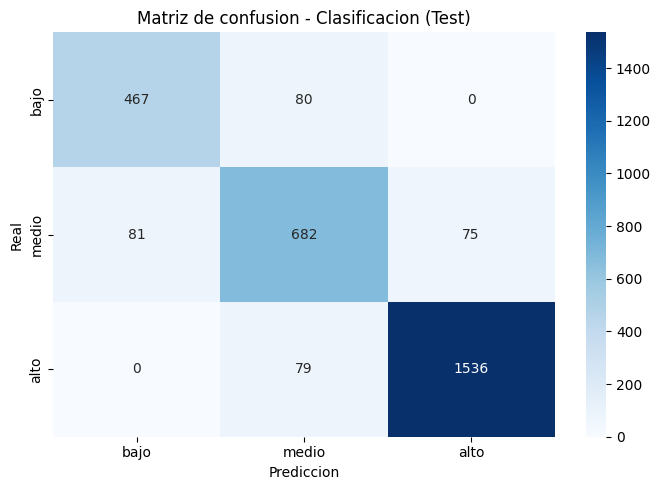

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 1) REGRESION
param_grid_reg = {
    'n_estimators': [150, 250],
    'learning_rate': [0.03, 0.1],
    'max_depth': [2, 3],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'subsample': [0.8]
}

gbr = GradientBoostingRegressor(random_state=42)
grid_reg = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_reg,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_reg.fit(X_train, y_train_reg)

best_reg = grid_reg.best_estimator_
pred_train_reg = best_reg.predict(X_train)
pred_test_reg = best_reg.predict(X_test)

mae_train_reg = mean_absolute_error(y_train_reg, pred_train_reg)
rmse_train_reg = mean_squared_error(y_train_reg, pred_train_reg) ** 0.5
r2_train_reg = r2_score(y_train_reg, pred_train_reg)

mae_test_reg = mean_absolute_error(y_test_reg, pred_test_reg)
rmse_test_reg = mean_squared_error(y_test_reg, pred_test_reg) ** 0.5
r2_test_reg = r2_score(y_test_reg, pred_test_reg)

print('=== REGRESION: GradientBoostingRegressor + GridSearch ===')
print('Mejores parametros:', grid_reg.best_params_)
print('\nMetricas TRAIN:')
print(f'MAE train: {mae_train_reg:.4f}')
print(f'RMSE train: {rmse_train_reg:.4f}')
print(f'R2 train: {r2_train_reg:.4f}')
print('\nMetricas TEST:')
print(f'MAE test: {mae_test_reg:.4f}')
print(f'RMSE test: {rmse_test_reg:.4f}')
print(f'R2 test: {r2_test_reg:.4f}')
print('\nGap train-test (sobreajuste potencial):')
print(f'Gap R2: {r2_train_reg - r2_test_reg:.4f}')
print(f'Gap RMSE: {rmse_test_reg - rmse_train_reg:.4f}')


# 2) CLASIFICACION
param_grid_clf = {
    'n_estimators': [150, 250],
    'learning_rate': [0.03, 0.1],
    'max_depth': [2, 3],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'subsample': [0.8]
}

gbc = GradientBoostingClassifier(random_state=42)
grid_clf = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid_clf,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
grid_clf.fit(X_train, y_train_clf)

best_clf = grid_clf.best_estimator_
pred_train_clf = best_clf.predict(X_train)
pred_test_clf = best_clf.predict(X_test)

acc_train_clf = accuracy_score(y_train_clf, pred_train_clf)
f1_train_clf = f1_score(y_train_clf, pred_train_clf, average='macro')
acc_test_clf = accuracy_score(y_test_clf, pred_test_clf)
f1_test_clf = f1_score(y_test_clf, pred_test_clf, average='macro')

print('\n=== CLASIFICACION: GradientBoostingClassifier + GridSearch ===')
print('Mejores parametros:', grid_clf.best_params_)
print('\nMetricas TRAIN:')
print(f'Accuracy train: {acc_train_clf:.4f}')
print(f'F1 macro train: {f1_train_clf:.4f}')
print('\nMetricas TEST:')
print(f'Accuracy test: {acc_test_clf:.4f}')
print(f'F1 macro test: {f1_test_clf:.4f}')
print('\nGap train-test (sobreajuste potencial):')
print(f'Gap Accuracy: {acc_train_clf - acc_test_clf:.4f}')
print(f'Gap F1 macro: {f1_train_clf - f1_test_clf:.4f}')
print('\nReporte de clasificacion (TEST):')
print(classification_report(y_test_clf, pred_test_clf))

matriz = confusion_matrix(y_test_clf, pred_test_clf, labels=['bajo', 'medio', 'alto'])
plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['bajo', 'medio', 'alto'],
    yticklabels=['bajo', 'medio', 'alto']
 )
plt.title('Matriz de confusion - Clasificacion (Test)')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

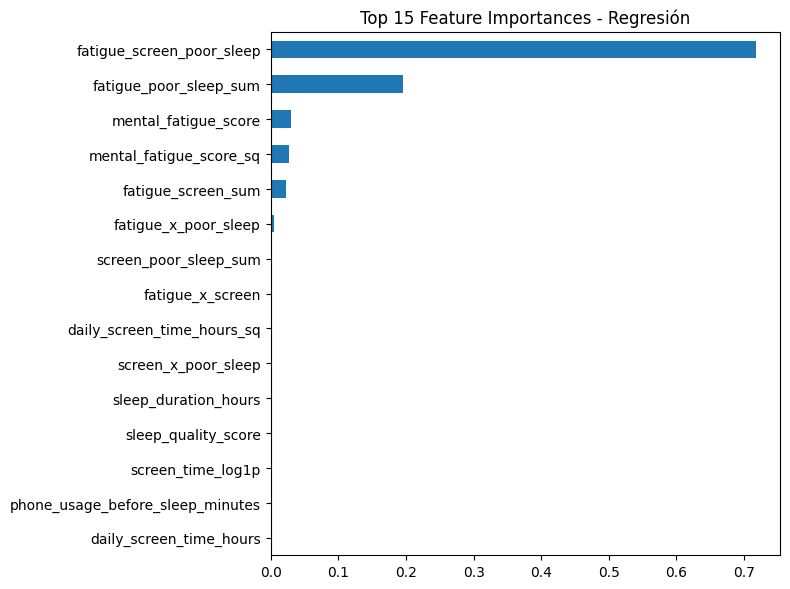

In [23]:
feat_imp = pd.Series(
    best_reg.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)

feat_imp.tail(15).plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Feature Importances - Regresión')
plt.tight_layout()
plt.show()